### Classification Metrics Clinic
1. Tune decision threshold beyond the default 0.5 to optimize for specific business objectives
2. Apply SMOTE and class weighting to handel severely imbalanced dataset
3. Build cost curves to select optimal operating points based on business penalties
4. Compare multiple imbalanced data techiniques systematically
5. Make production-aware deployment decisions
6. Translate model performance into business cost savings

In [4]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print('✓ All libraries loaded successfully!')

✓ All libraries loaded successfully!


In [5]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    weights=[0.99, 0.01], # 99% legitimate, 1% fraud
    flip_y=0.01,
    random_state=42
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [7]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(f"  Legitimate (0): {np.sum(y_train == 0)} ({np.mean(y_train == 0)*100:.1f}%)")
print(f"  Fraud (1): {np.sum(y_train == 1)} ({np.mean(y_train == 1)*100:.1f}%)")
print(f"\nImbalance ratio: {np.sum(y_train==0)/np.sum(y_train==1):.0f}:1")

Training set size: 7000
Test set size: 3000

Class distribution in training set:
  Legitimate (0): 6901 (98.6%)
  Fraud (1): 99 (1.4%)

Imbalance ratio: 70:1


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [9]:
y_proba = model.predict_proba(X_test_scaled)[:,1] #p(class=0),p(class=1)
y_pred_default = model.predict(X_test_scaled)

In [12]:
# Evaluate at default threshold
print("\n" + "="*70)
print("BASELINE MODEL (Threshold = 0.5)")
print("="*70)
print(f"Accuracy: {model.score(X_test_scaled, y_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_default, zero_division=0):.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()
print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")
print("="*70)


BASELINE MODEL (Threshold = 0.5)
Accuracy: 0.9880
Precision: 1.0000
Recall: 0.1429
F1 Score: 0.2500

Confusion Matrix:
  True Negatives (TN): 2958
  False Positives (FP): 0
  False Negatives (FN): 36
  True Positives (TP): 6


In [13]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

print("\n" + "="*70)
print("BASELINE CHECK: Majority Class Predictor")
print("="*70)
print(f"Baseline Model (Always Predict 'Legitimate'):")
print(f"  Accuracy: {baseline.score(X_test_scaled, y_test):.4f}")
print(f"  Recall on Fraud: {recall_score(y_test, baseline_pred, zero_division=0):.4f}")

print(f"\nOur Model (threshold=0.5):")
print(f"  Accuracy: {model.score(X_test_scaled, y_test):.4f}")
print(f"  Recall on Fraud: {recall_score(y_test, y_pred_default, zero_division=0):.4f}")

if abs(model.score(X_test_scaled, y_test) - baseline.score(X_test_scaled, y_test)) < 0.01:
    print("\n⚠️  WARNING: Model performance ≈ baseline!")
    print("   The model may be predicting majority class for everything.")
else:
    print("\n✓ Model outperforms baseline - learning signal detected.")
print("="*70)


BASELINE CHECK: Majority Class Predictor
Baseline Model (Always Predict 'Legitimate'):
  Accuracy: 0.9860
  Recall on Fraud: 0.0000

Our Model (threshold=0.5):
  Accuracy: 0.9880
  Recall on Fraud: 0.1429

⚠️  WARNING: Model performance ≈ baseline!
   The model may be predicting majority class for everything.


In [14]:
thresholds = np.linspace(0,1,101)
results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    })

results_df = pd.DataFrame(results)

In [15]:
results_df

,threshold,precision,recall,f1,tp,fp,fn,tn
0,0.00,0.014000,1.000000,0.027613,42,2958,0,0
1,0.01,0.030542,0.738095,0.058657,31,984,11,1974
2,0.02,0.053498,0.619048,0.098485,26,460,16,2498
3,0.03,0.081560,0.547619,0.141975,23,259,19,2699
4,0.04,0.120690,0.500000,0.194444,21,153,21,2805
...,...,...,...,...,...,...,...,...
96,0.96,0.000000,0.000000,0.000000,0,0,42,2958
97,0.97,0.000000,0.000000,0.000000,0,0,42,2958
98,0.98,0.000000,0.000000,0.000000,0,0,42,2958
99,0.99,0.000000,0.000000,0.000000,0,0,42,2958


In [16]:
max_f1_idx = results_df['f1'].idxmax()
optimal_f1_threshold = results_df.loc[max_f1_idx, 'threshold']

In [17]:
print("\n" + "="*70)
print("THRESHOLD OPTIMIZATION")
print("="*70)
print(f"Optimal threshold for F1 maximization: {optimal_f1_threshold:.2f}")
print(f"  F1 Score: {results_df.loc[max_f1_idx, 'f1']:.4f}")
print(f"  Precision: {results_df.loc[max_f1_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[max_f1_idx, 'recall']:.4f}")
print("="*70)


THRESHOLD OPTIMIZATION
Optimal threshold for F1 maximization: 0.13
  F1 Score: 0.4308
  Precision: 0.6087
  Recall: 0.3333


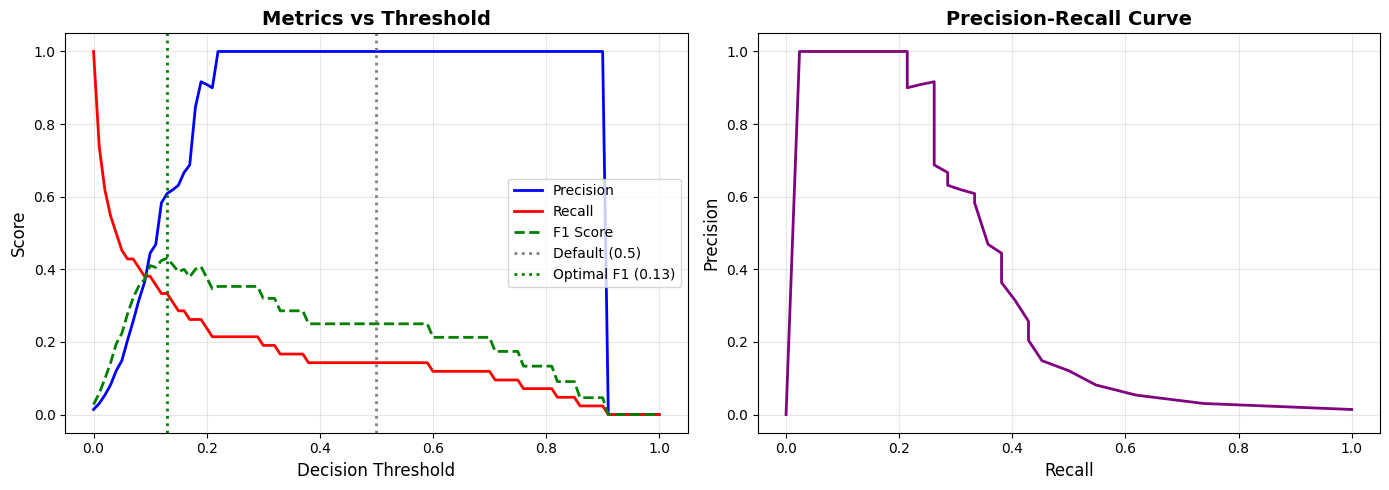


💡 Key Insight: Lower threshold → Higher recall, Lower precision
   Higher threshold → Lower recall, Higher precision


In [18]:
plt.figure(figsize=(14, 5))

# Plot 1: Precision and Recall vs Threshold
plt.subplot(1, 2, 1)
plt.plot(results_df['threshold'], results_df['precision'],
         label='Precision', linewidth=2, color='blue')
plt.plot(results_df['threshold'], results_df['recall'],
         label='Recall', linewidth=2, color='red')
plt.plot(results_df['threshold'], results_df['f1'],
         label='F1 Score', linewidth=2, color='green', linestyle='--')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)', linewidth=2)
plt.axvline(x=optimal_f1_threshold, color='green', linestyle=':',
            label=f'Optimal F1 ({optimal_f1_threshold:.2f})', linewidth=2)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(results_df['recall'], results_df['precision'], linewidth=2, color='purple')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Lower threshold → Higher recall, Lower precision")
print("   Higher threshold → Lower recall, Higher precision")

In [19]:
COST_FP = 10
COST_FN = 2000

print("\n" + "="*70)
print("BUSINESS COST STRUCTURE")
print("="*70)
print(f"False Positive (FP): ${COST_FP} (blocked legitimate transaction)")
print(f"False Negative (FN): ${COST_FN} (missed fraud)")
print(f"Cost Ratio (FN:FP): {COST_FN/COST_FP:.0f}:1")
print("="*70)


BUSINESS COST STRUCTURE
False Positive (FP): $10 (blocked legitimate transaction)
False Negative (FN): $2000 (missed fraud)
Cost Ratio (FN:FP): 200:1


In [20]:
# Define business costs
COST_FP = 10      # False positive: block legitimate transaction
COST_FN = 2000    # False negative: miss fraud

print("\n" + "="*70)
print("BUSINESS COST STRUCTURE")
print("="*70)
print(f"False Positive (FP): ${COST_FP} (blocked legitimate transaction)")
print(f"False Negative (FN): ${COST_FN} (missed fraud)")
print(f"Cost Ratio (FN:FP): {COST_FN/COST_FP:.0f}:1")
print("="*70)

# Calculate total cost for each threshold
results_df['total_cost'] = (results_df['fp'] * COST_FP) + (results_df['fn'] * COST_FN)

# Find cost-minimizing threshold
min_cost_idx = results_df['total_cost'].idxmin()
optimal_cost_threshold = results_df.loc[min_cost_idx, 'threshold']
min_total_cost = results_df.loc[min_cost_idx, 'total_cost']

default_cost = results_df[results_df['threshold'] == 0.5]['total_cost'].values[0]

print("\n" + "="*70)
print("COST ANALYSIS")
print("="*70)
print(f"Default threshold (0.5):")
print(f"  Total Cost: ${default_cost:,.0f}")
print(f"\nOptimal threshold ({optimal_cost_threshold:.2f}):")
print(f"  Total Cost: ${min_total_cost:,.0f}")
print(f"  FP: {results_df.loc[min_cost_idx, 'fp']:.0f}")
print(f"  FN: {results_df.loc[min_cost_idx, 'fn']:.0f}")
print(f"\n💰 Cost Savings: ${default_cost - min_total_cost:,.0f} ({(1 - min_total_cost/default_cost)*100:.1f}% reduction)")
print("="*70)


BUSINESS COST STRUCTURE
False Positive (FP): $10 (blocked legitimate transaction)
False Negative (FN): $2000 (missed fraud)
Cost Ratio (FN:FP): 200:1

COST ANALYSIS
Default threshold (0.5):
  Total Cost: $72,000

Optimal threshold (0.00):
  Total Cost: $29,580
  FP: 2958
  FN: 0

💰 Cost Savings: $42,420 (58.9% reduction)


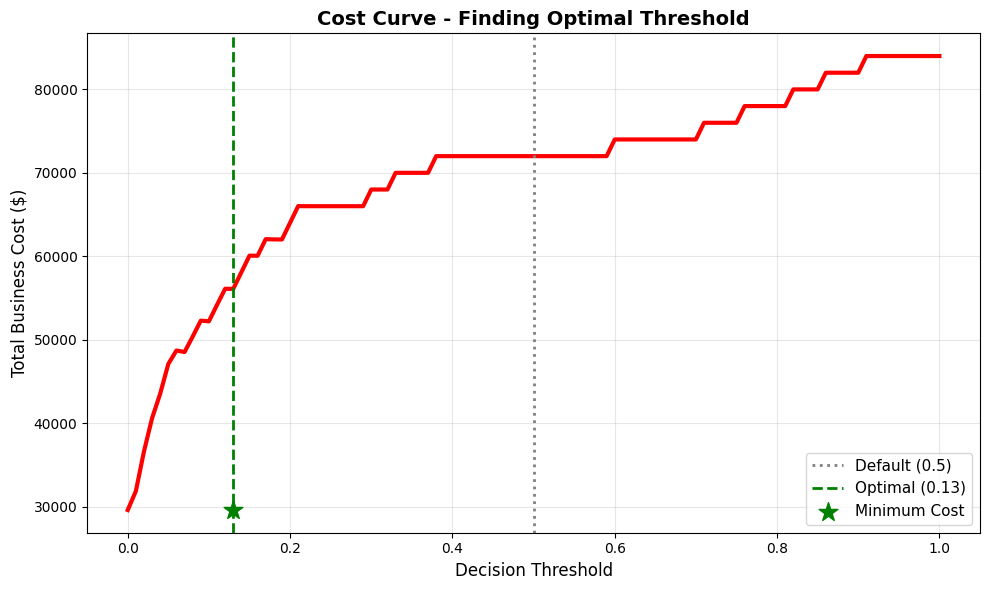

In [21]:
optimal_cost_threshold = 0.13
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['total_cost'], linewidth=3, color='red')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)', linewidth=2)
plt.axvline(x=optimal_cost_threshold, color='green', linestyle='--',
            label=f'Optimal ({optimal_cost_threshold:.2f})', linewidth=2)
plt.scatter([optimal_cost_threshold], [min_total_cost],
            color='green', s=200, zorder=5, marker='*', label='Minimum Cost')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Total Business Cost ($)', fontsize=12)
plt.title('Cost Curve - Finding Optimal Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print("\n" + "="*70)
print("SMOTE: SYNTHETIC MINORITY OVERSAMPLING")
print("="*70)

print(f"\nBefore SMOTE:")
print(f"  Class distribution: {Counter(y_train)}")
print(f"  Imbalance ratio: {np.sum(y_train==0) / np.sum(y_train==1):.1f}:1")


SMOTE: SYNTHETIC MINORITY OVERSAMPLING

Before SMOTE:
  Class distribution: Counter({np.int64(0): 6901, np.int64(1): 99})
  Imbalance ratio: 69.7:1


In [23]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Class distribution: {Counter(y_train_smote)}")
print(f"  Dataset size: {len(y_train)} → {len(y_train_smote)} (+{len(y_train_smote)-len(y_train)} samples)")


After SMOTE:
  Class distribution: Counter({np.int64(0): 6901, np.int64(1): 6901})
  Dataset size: 7000 → 13802 (+6802 samples)


In [24]:
# Train model on SMOTE'd data
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

print(f"\nModel Performance (SMOTE):")
print(f"  Accuracy: {model_smote.score(X_test_scaled, y_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_smote):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_smote):.4f}")

print(f"\nImprovement over Original:")
print(f"  Recall gain: {recall_score(y_test, y_pred_smote) - recall_score(y_test, y_pred_default):+.4f}")
print("="*70)


Model Performance (SMOTE):
  Accuracy: 0.7820
  Precision: 0.0419
  Recall: 0.6667
  F1 Score: 0.0789

Improvement over Original:
  Recall gain: +0.5238


In [25]:
print("\n" + "="*70)
print("RANDOM UNDERSAMPLING")
print("="*70)

# Apply random undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print(f"After Undersampling:")
print(f"  Class distribution: {Counter(y_train_under)}")
print(f"  Dataset size: {len(y_train)} → {len(y_train_under)} ({len(y_train)-len(y_train_under)} samples removed)")


RANDOM UNDERSAMPLING
After Undersampling:
  Class distribution: Counter({np.int64(0): 99, np.int64(1): 99})
  Dataset size: 7000 → 198 (6802 samples removed)


In [26]:
# Train model on undersampled data
model_under = LogisticRegression(max_iter=1000, random_state=42)
model_under.fit(X_train_under, y_train_under)
y_pred_under = model_under.predict(X_test_scaled)

print(f"\nModel Performance (Undersampling):")
print(f"  Accuracy: {model_under.score(X_test_scaled, y_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_under):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_under):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_under):.4f}")
print("="*70)


Model Performance (Undersampling):
  Accuracy: 0.6740
  Precision: 0.0282
  Recall: 0.6667
  F1 Score: 0.0542


In [27]:
print("\n" + "="*70)
print("CLASS WEIGHTING")
print("="*70)

# Calculate balanced weights automatically
n_samples = len(y_train)
n_classes = 2
n_samples_class_0 = np.sum(y_train == 0)
n_samples_class_1 = np.sum(y_train == 1)

weight_0 = n_samples / (n_classes * n_samples_class_0)
weight_1 = n_samples / (n_classes * n_samples_class_1)

print(f"Automatic Class Weights:")
print(f"  Legitimate (0): {weight_0:.4f}")
print(f"  Fraud (1): {weight_1:.4f}")
print(f"  Weight ratio: {weight_1/weight_0:.1f}:1")
print(f"\n→ Fraud misclassification is penalized {weight_1/weight_0:.0f}× more during training")

# Train model with class weights
model_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
model_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = model_weighted.predict(X_test_scaled)

print(f"\nModel Performance (Class Weighting):")
print(f"  Accuracy: {model_weighted.score(X_test_scaled, y_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_weighted):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_weighted):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_weighted):.4f}")
print("="*70)


CLASS WEIGHTING
Automatic Class Weights:
  Legitimate (0): 0.5072
  Fraud (1): 35.3535
  Weight ratio: 69.7:1

→ Fraud misclassification is penalized 70× more during training

Model Performance (Class Weighting):
  Accuracy: 0.7700
  Precision: 0.0398
  Recall: 0.6667
  F1 Score: 0.0751


In [28]:
print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON")
print("="*70)

comparison_data = {
    'Approach': ['Original', 'SMOTE', 'Undersampling', 'Class Weighting'],
    'Precision': [
        precision_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_under),
        precision_score(y_test, y_pred_weighted)
    ],
    'Recall': [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_weighted)
    ],
    'F1': [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_weighted)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

print(f"\n✓ Best Recall: {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Approach']} ({comparison_df['Recall'].max():.4f})")
print(f"✓ Best F1: {comparison_df.loc[comparison_df['F1'].idxmax(), 'Approach']} ({comparison_df['F1'].max():.4f})")
print("="*70)


COMPREHENSIVE COMPARISON

       Approach  Precision   Recall       F1
       Original   1.000000 0.142857 0.250000
          SMOTE   0.041916 0.666667 0.078873
  Undersampling   0.028226 0.666667 0.054159
Class Weighting   0.039773 0.666667 0.075067

✓ Best Recall: SMOTE (0.6667)
✓ Best F1: Original (0.2500)


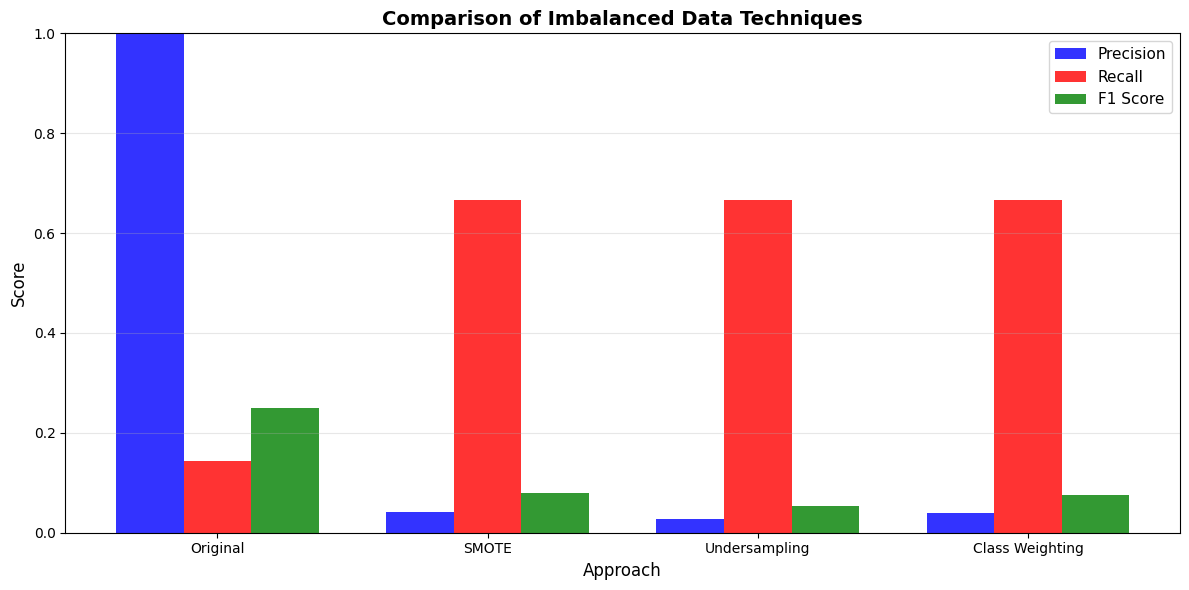

In [29]:
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.25

plt.bar(x - width, comparison_df['Precision'], width, label='Precision',
        color='blue', alpha=0.8)
plt.bar(x, comparison_df['Recall'], width, label='Recall',
        color='red', alpha=0.8)
plt.bar(x + width, comparison_df['F1'], width, label='F1 Score',
        color='green', alpha=0.8)

plt.xlabel('Approach', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Imbalanced Data Techniques', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Approach'])
plt.legend(fontsize=11)
plt.ylim(0, 1.0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()